In [1]:
import torch
from dataclasses import dataclass
from typing import Optional
# from ome

from icl import generate_dual_task_batch, get_distributions, MinimalTransformer, initialize_model, get_triggers

In [37]:
@dataclass
class cfg:
    vocab_size: int =  5 # Vocabulary size
    seq_len: int = 10 # Sequence length
    d_model: int = 512 # Model dimension
    rank: int = 16   # rank or matrices
    dropout: float = 0.0 # Dropout rate
    lin_attn: bool = True # Whether to use linear attention or not
    beta: float = 0.5 # Scaling factor for the output logits (inverse of the temperature)
    b_type: str = 'spiked' # P_b distribution type: dirichlet or spiked
    alpha_d: float = 0.1 # Dirichlet concentration parameter for bigram distribution (only used if b_type is dirichlet or u_type is dirichlet)
    alpha_z: Optional[float] = 1.0 # Exponent for the Zipf distribution used to generate the unigram distribution P_u if b_type is 'spiked' and u_type is 'zipf'
    u_type: Optional[str] = 'uniform' # P_u distribution type: dirichlet or zipf (only used if b_type is spiked)
    beta: Optional[float] = 0. # Beta parameter for spiked bigram distribution (only used if b_type is spiked)
    fix_trig: bool = True # Whether to fix the trigger tokens or not
    trig_type: Optional[str] = 'freq' # Type of fixed trigger tokens if fix_trig is True (options are 'freq', 'rare' and 'rand')
    batch_size: int = 1024 # Batch size for training
    test_size: int = 200 # Number of samples in the test set
    K : int = 4 # Number of trigger tokens  


# Define device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Define distributions
distributions = get_distributions(cfg, cfg.vocab_size, device=device)

# Initialize model
model = MinimalTransformer(cfg).to(device)
model = initialize_model(model)

# Define triggers
trigger_set = get_triggers(cfg, distributions['P_t'])#.to(device)

Generating spiked bigram distribution with and beta =  0.0
Generating unigram distribution from a uniform distribution
Using fixed freq trigger set
Length of trigger set: 4, Trigger set: [0, 1, 2, 3]


In [50]:
batch = generate_dual_task_batch(3,cfg.seq_len,cfg.K,distributions,trigger_set,device=device)

In [51]:
print("Batch generated successfully.")
for key, value in batch.items():
    print(f"{key}: {value.shape if isinstance(value, torch.Tensor) else value}")

Batch generated successfully.
sequence: torch.Size([3, 11])
trigger_set: torch.Size([3, 4])
output_set: torch.Size([3, 4])
counts: torch.Size([3, 10])
is_trigg: torch.Size([3, 10])
mask: torch.Size([3, 10, 10])


In [52]:
logits = model(batch['sequence'][:, :-1].to(device), batch['mask'].to(device)) # shape (batch_size, seq_len, vocab_size)
print("Logits generated successfully.")
print(f"logits: {logits.shape}")

Logits generated successfully.
logits: torch.Size([3, 10, 5])


In [53]:
# generate a mask to apply to the logits (shape(B,L,V)) such that each element (b,l,v) is true
# it the input token at position l in batch b is a trigger and the counts for that trigger are larger than 1
# and the corresponding output token is v. This mask will be used to compute the on-target and off-target logits for each trigger token in the batch.

on_target_mask = batch["is_trigg"].bool().unsqueeze(-1) & (batch["counts"] > 1).unsqueeze(-1) 
on_target_mask = on_target_mask & (torch.arange(logits.size(-1), device=logits.device).view(1, 1, -1) == batch["sequence"][:, 1:].unsqueeze(-1))

print(batch["sequence"],f'\n')
print(batch["is_trigg"],f'\n')
print(batch["counts"],f'\n')
print(on_target_mask)

print(logits[on_target_mask])


tensor([[2, 4, 3, 4, 1, 3, 4, 0, 2, 4, 4],
        [4, 4, 2, 0, 1, 4, 3, 1, 4, 3, 1],
        [2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]], device='cuda:0') 

tensor([[1, 0, 1, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 1, 1, 1, 0, 1, 1, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0') 

tensor([[1, 1, 1, 2, 1, 2, 3, 1, 2, 4],
        [1, 2, 1, 1, 1, 3, 1, 2, 4, 2],
        [1, 1, 2, 2, 3, 3, 4, 4, 5, 5]], device='cuda:0') 

tensor([[[False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False,  True],
         [False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False,  True],
         [False, False, False, False, False]],

        [[False, False, False, False, False],
         [False, False, False, False, False],
         [False, 

In [49]:
batch["sequence"][:, 1:].unsqueeze(-1)

tensor([[[3],
         [2],
         [1],
         [4],
         [1],
         [4],
         [2],
         [1],
         [4],
         [4]]], device='cuda:0')

# Plots

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from icl.evaluation.utils import on_off_masks
from tracklab import ExperimentReader
from configurations.plot_config import create_fig, set_font_sizes, apply_general_styles
apply_general_styles()
set_font_sizes(conf='tight')

In [2]:
# Define a function to plot empty squares for mask=1 on an existing axis
def plot_mask_squares(ax, mask,lw=0.5,color='red',alpha=1.0):
    """
    Plots empty squares on the given axis where mask=1.

    Parameters:
    ax : matplotlib.axes.Axes
        The axis on which to plot the squares.
    mask : numpy.ndarray
        A 2D array where squares are drawn for elements equal to 1.
    """
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j] == 1:
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=lw, alpha=alpha)
                ax.add_patch(rect)
    ax.set_xlim(-0.5, mask.shape[1] - 0.5)
    ax.set_ylim(-0.5, mask.shape[0] - 0.5)
    ax.invert_yaxis()
    ax.set_aspect('equal')


In [50]:
experiment_name = "logits"
reader = ExperimentReader(experiment_name, base_dir='../data')
run_id = reader.list_runs()[-1]
print(f"Loading run {run_id} from experiment {experiment_name}")

df = reader.load_metrics(run_id)
data = df.pivot(index='step', columns='metric', values='value').reset_index()

list_artifacts = reader.list_artifacts(run_id)
matrix_steps = list_artifacts['step'][1:].astype(int).to_list()
steps_to_plot = [1367,1472,1578,1683]
logits_to_plot = [reader.load_artifact(run_id,f'logits_step_{step}.npy') for step in steps_to_plot]
batch = reader.load_artifact(run_id,'sub_batch.pkl')
print(f"Matrix steps: {matrix_steps}")
print(list_artifacts)
print(logits_to_plot[0].shape)
for key, value in batch.items():
    print(f"{key}")
    print(f"{value.shape if isinstance(value, torch.Tensor) else value}")

i_batch_list = np.argsort(np.max(logits_to_plot[-1].reshape(logits_to_plot[-1].shape[0], -1), axis=1))[::-1]
# print(f"Batch index with highest logits: {i_batch}")
vocab_size = logits_to_plot[0].shape[-1]

Loading run run_001 from experiment logits
Matrix steps: [0, 105, 210, 315, 420, 526, 631, 736, 841, 946, 1052, 1157, 1262, 1367, 1472, 1578, 1683, 1788, 1893, 1999]
      step                  file
0      NaN         sub_batch.pkl
1      0.0     logits_step_0.npy
2    105.0   logits_step_105.npy
3    210.0   logits_step_210.npy
4    315.0   logits_step_315.npy
5    420.0   logits_step_420.npy
6    526.0   logits_step_526.npy
7    631.0   logits_step_631.npy
8    736.0   logits_step_736.npy
9    841.0   logits_step_841.npy
10   946.0   logits_step_946.npy
11  1052.0  logits_step_1052.npy
12  1157.0  logits_step_1157.npy
13  1262.0  logits_step_1262.npy
14  1367.0  logits_step_1367.npy
15  1472.0  logits_step_1472.npy
16  1578.0  logits_step_1578.npy
17  1683.0  logits_step_1683.npy
18  1788.0  logits_step_1788.npy
19  1893.0  logits_step_1893.npy
20  1999.0  logits_step_1999.npy
(100, 64, 64)
sequence
torch.Size([100, 65])
trigger_set
torch.Size([100, 8])
output_set
torch.Size([100, 8]

In [ ]:
np.max(logits_to_plot[-1].reshape(logits_to_plot[-1].shape[0], -1), axis=1)

(100,)

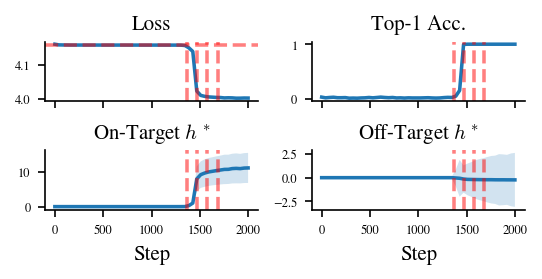

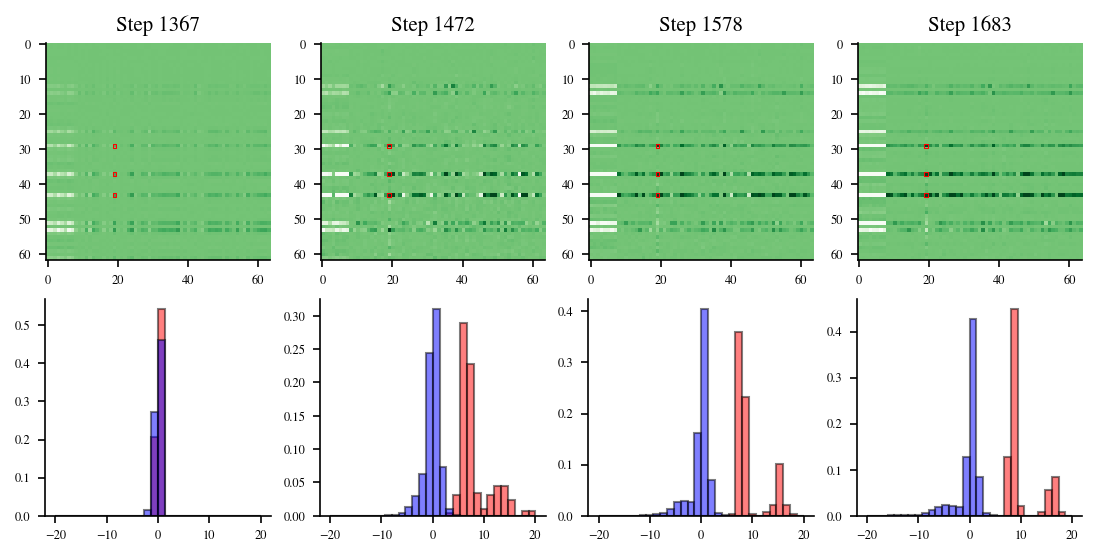

In [54]:
config = {
    'loss' : {'title': 'Loss'},
    'top1_accuracy' : {'title': 'Top-1 Acc.'},
    'on_target_mean' : {'title': r'On-Target $h^*$'},
    'off_target_mean' : {'title': r'Off-Target $h^*$'},
}
titles = ["Loss", "Top-1 Acc.", "On-Target Logits", "Off-Target Logits"]

# First plot for metrics
fig , axes = create_fig(nrows=2,ncols=2)

axes = axes.flatten()

for i , k  in enumerate(config.keys()):
    axes[i].plot(data['step'],data[k])
    axes[i].set_title(config[k]['title'])
    if i == 0 : axes[i].axhline(np.log(vocab_size), color='r', linestyle='--', alpha=0.5, label='Random Guess')
    if i > 1:
        k_std = k.replace('mean','std')
        axes[i].set_xlabel("Step")
        axes[i].fill_between(data['step'],data[k]-data[k_std],data[k]+data[k_std],alpha=0.2)
    for step in steps_to_plot:
        axes[i].axvline(x=step, color='r', linestyle='--', alpha=0.5)

# Second Plot for Logits
i_batch = i_batch_list[0]
fig , axes = create_fig(ncols=len(logits_to_plot),nrows=2,size='double',h=0.5,sharex=False)

for i, logits in enumerate(logits_to_plot):
    log = logits[i_batch][2:]
    on_mask, off_mask, all_mask = on_off_masks(logits.shape,batch)
    on_logits = logits[on_mask]
    off_logits = logits[off_mask]
    all_logits = logits[all_mask]

    im = axes[0,i].imshow(log,cmap='Greens',vmin=-3,vmax=3)
    plot_mask_squares(axes[0,i],on_mask[i_batch][2:],lw=0.5,color='red',alpha=1.0)
    # cbar = fig.colorbar(im, ax=axes[0,i],fraction=0.02, pad=0.04)
    # Plot the logits
    axes[0,i].set_title(f"Step {steps_to_plot[i]}")

    # Plot the distributions
    
    
    for x,c in zip([on_logits,off_logits],['red','blue']):
        axes[1,i].hist(x,range=(-20,20),bins=30,alpha=0.5,label='All',color=c,density=True,histtype='barstacked',rwidth=1,edgecolor='black')
    # axes[1,i].hist(off_logits,bins=20,alpha=0.5,label='All',color='blue',density=True,histtype='barstacked',rwidth=1,edgecolor='black')
    # axes[1,i].set_yscale('log')

In [101]:
log

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-6.34540245e-03,  2.51682242e-04,  2.81601283e-03,
         8.48375913e-03,  6.00763503e-03,  6.42855512e-03,
        -2.97724688e-03, -1.29470322e-03, -4.14582668e-03,
         4.34559062e-02,  2.87182606e-03,  1.79837004e-03,
         8.42778292e-03, -1.80862192e-03,  1.12730637e-03,
         3.07540735e-03],
       [-5.55547711e-04, -8.15649517e